# Activity 2: Analyzing Different Scenarios and Generating the Appropriate Visualization

We'll be working with the 120 years of Olympic History dataset acquired by Randi Griffin from https://www.sports-reference.com/ and made available on the GitHub repository of this book. Your assignment is to identify the top five sports based on the largest number of medals awarded in the year 2016, and then perform the following analysis:

1.  Generate a plot indicating the number of medals awarded in each of the top five sports in 2016.
2.  Plot a graph depicting the distribution of the age of medal winners in the top five sports in 2016.
3.  Find out which national teams won the largest number of medals in the top five sports in 2016.
4.  Observe the trend in the average weight of male and female athletes winning in the top five sports in 2016.

## High-Level Steps

1.  Download the dataset and format it as a pandas DataFrame.
2.  Filter the DataFrame to only include the rows corresponding to medal winners from 2016.
3.  Find out the medals awarded in 2016 for each sport.
4.  List the top five sports based on the largest number of medals awarded. Filter the DataFrame one more time to only include the records for the top five sports in 2016.
5.  Generate a bar plot of record counts corresponding to each of the top five sports.
6.  Generate a histogram for the Age feature of all medal winners in the top five sports (2016).
7.  Generate a bar plot indicating how many medals were won by each country's team in the top five sports in 2016.
8.  Generate a bar plot indicating the average weight of players, categorized based on gender, winning in the top five sports in 2016.

In [1]:
## Step 1: Import des bibliothèques et chargement des données

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/athlete_events.csv"
df = pd.read_csv(url)

print("Dimensions du dataset :", df.shape)
print("\n5 premières lignes :")
print(df.head())

Dimensions du dataset : (271116, 15)

5 premières lignes :
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball   NaN  
1      Judo

In [2]:
## Step 2: Filtrer les données pour les médaillés de 2016 et identifier le top 5 des sports

# Filtrer sur l'année 2016 et les athlètes ayant remporté une médaille
df_2016 = df[(df['Year'] == 2016) & (df['Medal'].notna())]

# Compter le nombre de médailles par sport et récupérer le top 5
medals_per_sport = df_2016['Sport'].value_counts()
top5_sports = medals_per_sport.head(5).index.tolist()

print("Top 5 sports par nombre de médailles en 2016 :")
print(medals_per_sport.head(5))

# Filtrer le DataFrame sur le top 5 des sports
df_top5 = df_2016[df_2016['Sport'].isin(top5_sports)]
print("\nNombre d'entrées dans le top 5 :", len(df_top5))

Top 5 sports par nombre de médailles en 2016 :
Sport
Athletics    192
Swimming     191
Rowing       144
Football     106
Hockey        99
Name: count, dtype: int64

Nombre d'entrées dans le top 5 : 732


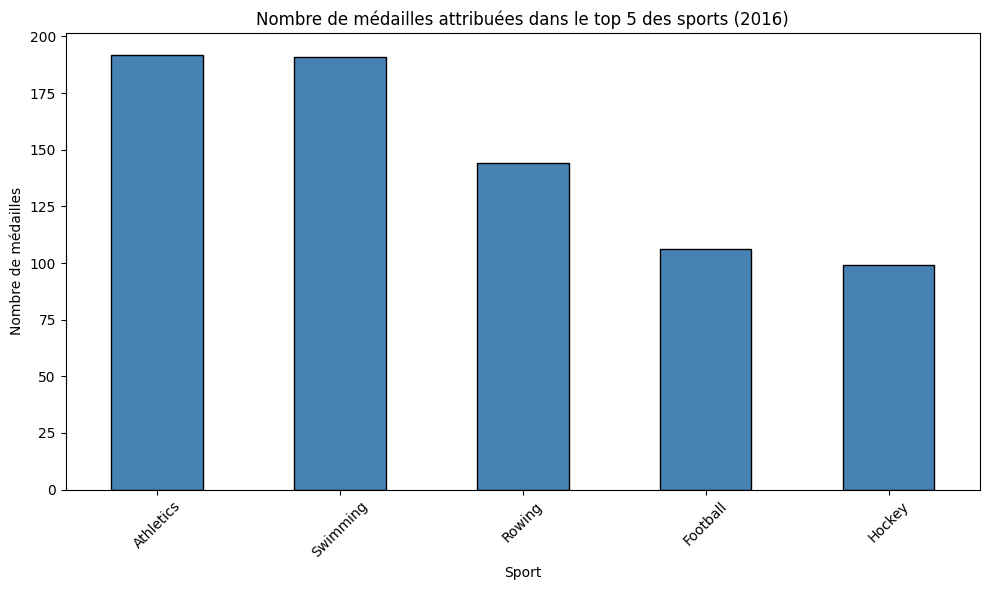

In [3]:
## Plot 1: Nombre de médailles par sport (Top 5, 2016)

plt.figure(figsize=(10, 6))
medals_per_sport[top5_sports].plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel("Sport")
plt.ylabel("Nombre de médailles")
plt.title("Nombre de médailles attribuées dans le top 5 des sports (2016)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

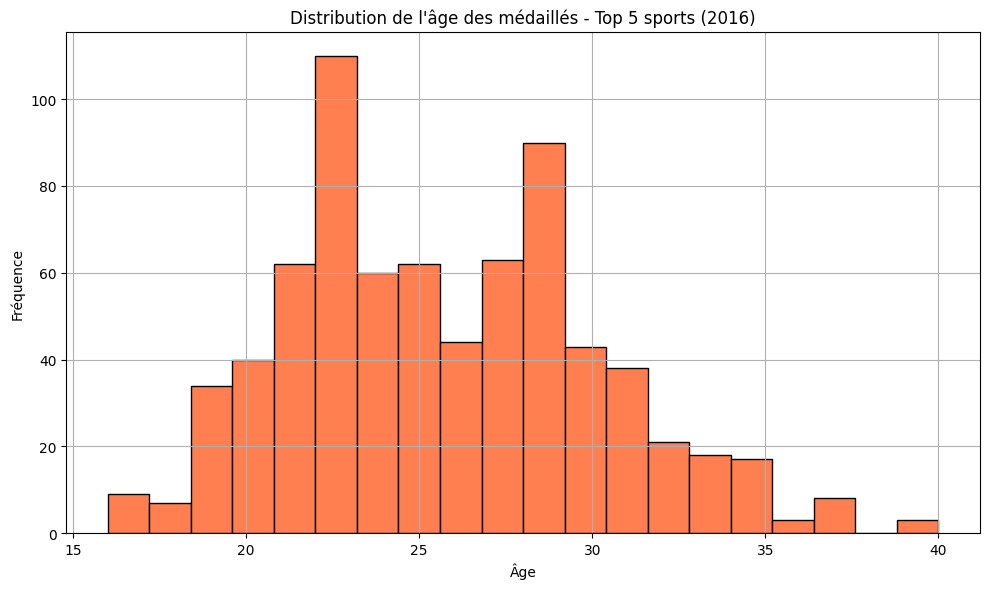

In [4]:
## Plot 2: Distribution de l'âge des médaillés dans le top 5 des sports (2016)

plt.figure(figsize=(10, 6))
df_top5['Age'].dropna().hist(bins=20, color='coral', edgecolor='black')
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.title("Distribution de l'âge des médaillés - Top 5 sports (2016)")
plt.tight_layout()
plt.show()

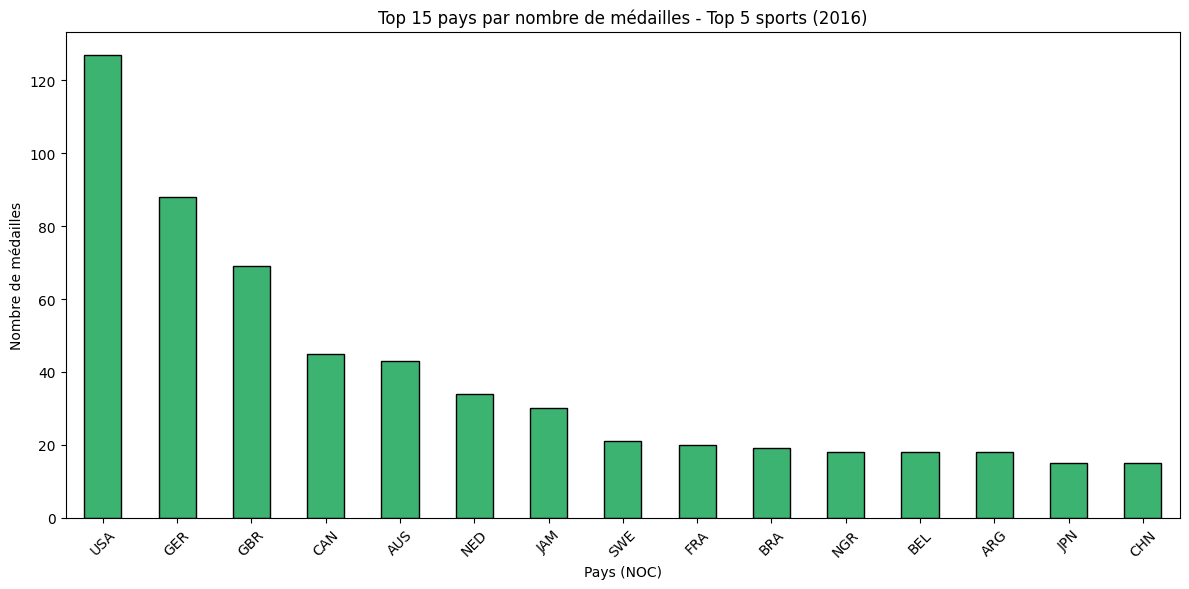

In [5]:
## Plot 3: Nombre de médailles par équipe nationale dans le top 5 des sports (2016)

medals_by_country = df_top5['NOC'].value_counts().head(15)

plt.figure(figsize=(12, 6))
medals_by_country.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.xlabel("Pays (NOC)")
plt.ylabel("Nombre de médailles")
plt.title("Top 15 pays par nombre de médailles - Top 5 sports (2016)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

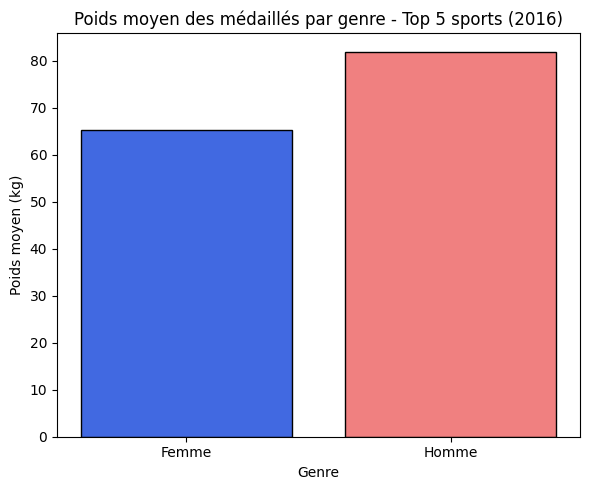

In [6]:
## Plot 4: Poids moyen des médaillés par genre dans le top 5 des sports (2016)

avg_weight = df_top5.groupby('Sex')['Weight'].mean().reset_index()
avg_weight['Sex'] = avg_weight['Sex'].map({'M': 'Homme', 'F': 'Femme'})

plt.figure(figsize=(6, 5))
plt.bar(avg_weight['Sex'], avg_weight['Weight'], color=['royalblue', 'lightcoral'], edgecolor='black')
plt.xlabel("Genre")
plt.ylabel("Poids moyen (kg)")
plt.title("Poids moyen des médaillés par genre - Top 5 sports (2016)")
plt.tight_layout()
plt.show()